# 07 · Analyst Review

Measure variation across the 50 synthetic fraud analysts and compare capacity-aware assignment policies on a later alert month.

## Reading guide

This notebook is part of a connected workflow. It states the decision being made, shows the supporting checks and records limitations alongside the result. Source files are never modified in place.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = Path(os.environ.get("FIFAR_DATA_DIR", PROJECT_ROOT / "data" / "raw" / "FiFAR"))
REPORTS = PROJECT_ROOT / "reports"
IMAGES = PROJECT_ROOT / "images"

sns.set_theme(style="whitegrid")
CORAL = "#F08FA0"
TEAL = "#0E6268"
DARK = "#15262B"

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "Set FIFAR_DATA_DIR to the extracted official FiFAR directory before running this notebook."
    )

In [2]:
alerts = pd.read_parquet(DATA_ROOT / "alert_data" / "processed_data" / "alerts.parquet")
predictions = pd.read_parquet(DATA_ROOT / "synthetic_experts" / "expert_predictions.parquet")
parameters = pd.read_parquet(DATA_ROOT / "synthetic_experts" / "expert_parameters.parquet")
assert alerts.index.is_unique and predictions.index.is_unique
assert set(alerts.index) == set(predictions.index)
predictions = predictions.reindex(alerts.index)
assert alerts.index.equals(predictions.index)

## 1. Analyst-level performance

In [3]:
truth = alerts["fraud_bool"].to_numpy()
analyst_rows = []
for analyst in predictions.columns:
    decision = predictions[analyst].to_numpy()
    tp = int(((decision == 1) & (truth == 1)).sum())
    fp = int(((decision == 1) & (truth == 0)).sum())
    fn = int(((decision == 0) & (truth == 1)).sum())
    tn = int(((decision == 0) & (truth == 0)).sum())
    analyst_rows.append({
        "analyst": analyst,
        "accuracy": (tp + tn) / len(truth),
        "precision": tp / (tp + fp) if tp + fp else 0,
        "recall": tp / (tp + fn) if tp + fn else 0,
        "positive_rate": (tp + fp) / len(truth),
    })
analysts = pd.DataFrame(analyst_rows).sort_values("accuracy", ascending=False)
analysts.head(10)

,analyst,accuracy,precision,recall,positive_rate
38,standard#38,0.961335,0.880108,0.788638,0.108680
33,standard#33,0.931291,0.728823,0.690361,0.114885
25,standard#25,0.924107,0.678571,0.711093,0.127098
23,standard#23,0.907256,0.597938,0.718363,0.145712
39,standard#39,0.905330,0.581975,0.778945,0.162334
27,standard#27,0.901999,0.581004,0.688476,0.143720
17,standard#17,0.891091,0.535348,0.772752,0.175070
8,standard#8,0.885801,0.520774,0.732364,0.170564
16,standard#16,0.879792,0.503072,0.727518,0.175397
37,standard#37,0.872608,0.484912,0.809101,0.202371


In [4]:
analysts.describe().T

,count,mean,std,min,25%,50%,75%,max
accuracy,50.0,0.707299,0.161340,0.330906,0.586498,0.715123,0.854214,0.961335
precision,50.0,0.340888,0.166069,0.151870,0.216420,0.276375,0.442537,0.880108
recall,50.0,0.843123,0.086382,0.688476,0.769319,0.842757,0.906233,0.985460
positive_rate,50.0,0.375932,0.179549,0.108680,0.216576,0.365766,0.517634,0.786787


Accuracy varies widely across the synthetic team. It must be interpreted with precision, recall and decision rate because the alert population remains imbalanced.

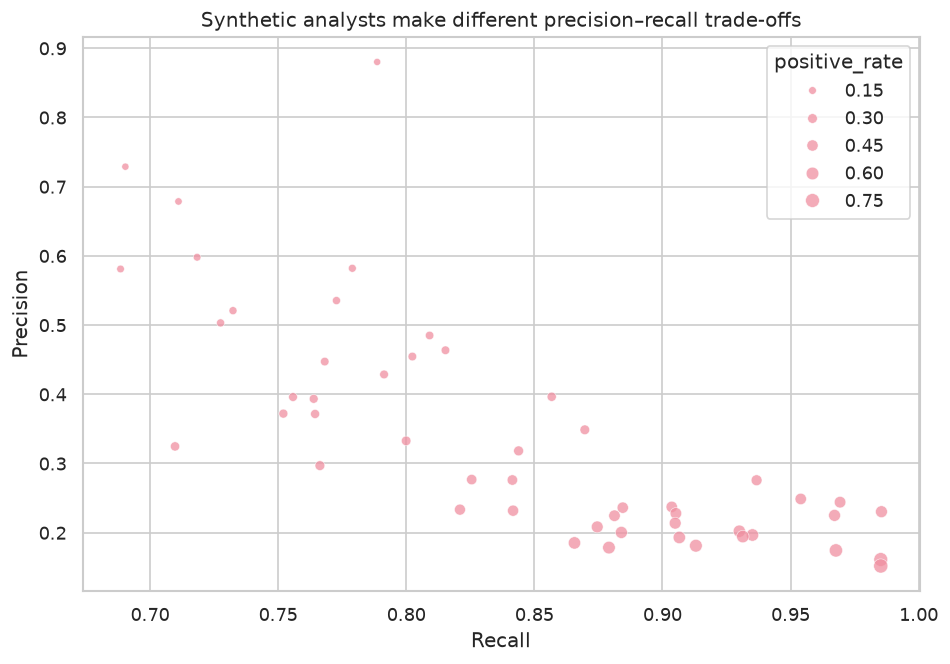

In [5]:
fig, axis = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=analysts, x="recall", y="precision", size="positive_rate", color=CORAL, alpha=.75, ax=axis)
axis.set(title="Synthetic analysts make different precision–recall trade-offs", xlabel="Recall", ylabel="Precision")
plt.show()

## 2. Capacity scenarios

In [6]:
capacity_files = sorted((DATA_ROOT / "testbed" / "test").glob("*/capacity.csv"))
batch_files = sorted((DATA_ROOT / "testbed" / "test").glob("*/batches.csv"))
pd.Series({"test_capacity_files": len(capacity_files), "test_batch_files": len(batch_files)})

test_capacity_files    25
test_batch_files       25
dtype: int64

In [7]:
pd.read_csv(capacity_files[0]).head(), pd.read_csv(batch_files[0]).head()

(   batch_id  batch_size  standard#0  ...  standard#47  standard#48  standard#49
0         1        4457           0  ...            0            0            0

[1 rows x 52 columns],    case_id  batch
0   935715      1
1   935859      1
2   990777      1
3   910095      1
4   910958      1)

## 3. Historical estimation and final test

Analyst skill is estimated from alert months 3–6. Month 7 remains outside this estimation and is used to compare 25 supplied team scenarios. Score bands are fitted on the historical alerts only.

In [8]:
review = json.loads((REPORTS / 'review_strategy_metrics.json').read_text())
pd.Series(review['data_split'])

historical_alerts           26165
test_alerts                  4457
historical_months    [3, 4, 5, 6]
test_month                      7
score_bands                    10
dtype: object

## 4. Assignment policies

- **Random capacity:** distributes cases randomly within each active analyst's limit.
- **Global skill:** prioritises analysts with the strongest historical correctness where review is expected to improve on the screening decision.
- **Risk-band specialist:** estimates each analyst's correctness within ten historical score bands, with smoothing towards their overall result.

Every policy respects the supplied analyst capacities. Unreviewed alerts retain the screening decision.

In [9]:
strategy = pd.DataFrame(review["strategy_summary"])
display_columns = [
    "strategy", "scenarios", "mean_accuracy", "mean_precision", "mean_recall",
    "mean_false_positive", "mean_false_negative", "mean_human_reviews",
]
strategy[display_columns].sort_values("mean_accuracy", ascending=False)

,strategy,scenarios,mean_accuracy,mean_precision,mean_recall,mean_false_positive,mean_false_negative,mean_human_reviews
2,risk_band_specialist,25,0.609361,0.277829,0.900591,1670.40,70.68,4052.0
0,global_skill,25,0.607871,0.277469,0.903404,1679.04,68.68,4052.0
1,random_capacity,25,0.571541,0.261234,0.917300,1850.84,58.80,4052.0


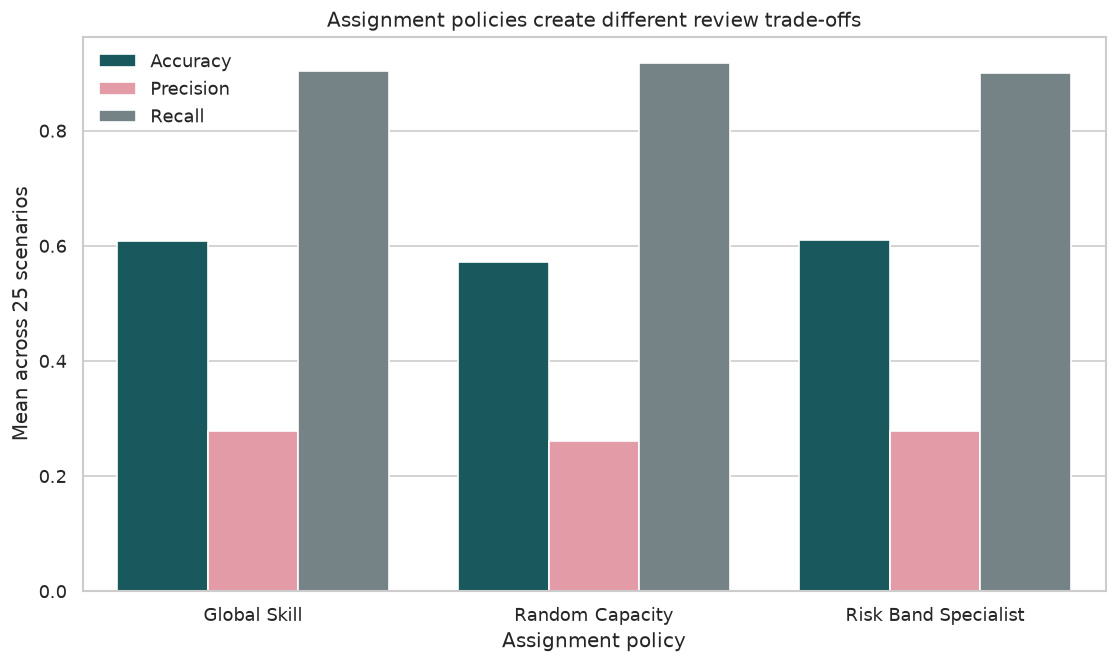

In [10]:
plot_data = strategy.melt(
    id_vars="strategy",
    value_vars=["mean_accuracy", "mean_precision", "mean_recall"],
    var_name="metric",
    value_name="value",
)
plot_data["metric"] = plot_data["metric"].str.replace("mean_", "", regex=False).str.title()
plot_data["policy"] = plot_data["strategy"].str.replace("_", " ", regex=False).str.title()
fig, axis = plt.subplots(figsize=(11, 6))
sns.barplot(data=plot_data, x="policy", y="value", hue="metric", palette=[TEAL, CORAL, "#728489"], ax=axis)
axis.set(title="Assignment policies create different review trade-offs", xlabel="Assignment policy", ylabel="Mean across 25 scenarios")
axis.legend(title=None, frameon=False)
plt.show()

## 5. Result

Risk-band assignment achieves the highest mean accuracy and precision, while random assignment retains slightly more fraud cases. The gain over global-skill assignment is small. This is a trade-off, not evidence that a single policy is best for every operating cost.

In [11]:
random_row = strategy.set_index("strategy").loc["random_capacity"]
specialist_row = strategy.set_index("strategy").loc["risk_band_specialist"]
pd.Series({
    "accuracy_change_vs_random_pp": (specialist_row.mean_accuracy - random_row.mean_accuracy) * 100,
    "precision_change_vs_random_pp": (specialist_row.mean_precision - random_row.mean_precision) * 100,
    "recall_change_vs_random_pp": (specialist_row.mean_recall - random_row.mean_recall) * 100,
    "mean_false_positives_avoided": random_row.mean_false_positive - specialist_row.mean_false_positive,
})

accuracy_change_vs_random_pp       3.781916
precision_change_vs_random_pp      1.659502
recall_change_vs_random_pp        -1.670886
mean_false_positives_avoided     180.440000
dtype: float64

## Conclusion

Capacity and analyst selection materially change the final alert decisions. Historical specialisation can reduce unnecessary positive decisions, but the accompanying recall loss must be assessed against fraud cost and review policy.